In [2]:
import os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    module="keras.src.export.tf2onnx_lib"
)
import tensorflow as tf
import pandas as pd
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Conv2D, LSTM, Input, MaxPooling2D, Reshape, Bidirectional, StringLookup
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard
import cv2
import numpy as np
import matplotlib.pyplot as plt
from src.constants import *
from src.helpers import load_img
from sklearn.model_selection import train_test_split
from tensorflow.keras.backend import ctc_batch_cost, int_shape, ctc_decode
import editdistance

### File paths and labels

In [22]:
df = pd.read_csv(TRAIN_TSV, sep='\t', header=None, names=['file', 'label'])
df = df.dropna(subset=['label']).reset_index(drop=True) # 2 entries with no label
image_paths = [TRAIN_DIR + "/" + f for f in df["file"].values]
labels = df["label"].values

df

,file,label
0,aa1.png,Молдова
1,aa1007.png,продолжила борьбу
2,aa101.png,разработанные
3,aa1012.png,Плачи
4,aa1013.png,Гимны богам
...,...,...
72279,yob20539.png,Ответственность в/сл-
72280,yob20543.png,независимо
72281,yob20544.png,от воинского звания
72282,yob20545.png,воинской


### Alphabet of possible values

In [25]:
import unicodedata
chars = list(set(char for label in labels for char in label))

for char in chars:
    script = unicodedata.name(char, 'idk')
    print(f"{char}: {script}")

print(max([len(label) for label in labels])) # the kaggle page said 40, this is just to confirm it
#len(chars) 107

with open("chars.txt", "w") as file:
    for c in chars:
        file.write(c)

Т: CYRILLIC CAPITAL LETTER TE
К: CYRILLIC CAPITAL LETTER KA
с: CYRILLIC SMALL LETTER ES
Е: CYRILLIC CAPITAL LETTER IE
u: LATIN SMALL LETTER U
ъ: CYRILLIC SMALL LETTER HARD SIGN
х: CYRILLIC SMALL LETTER HA
+: PLUS SIGN
): RIGHT PARENTHESIS
o: LATIN SMALL LETTER O
Н: CYRILLIC CAPITAL LETTER EN
1: DIGIT ONE
С: CYRILLIC CAPITAL LETTER ES
Г: CYRILLIC CAPITAL LETTER GHE
s: LATIN SMALL LETTER S
Я: CYRILLIC CAPITAL LETTER YA
4: DIGIT FOUR
": QUOTATION MARK
н: CYRILLIC SMALL LETTER EN
з: CYRILLIC SMALL LETTER ZE
5: DIGIT FIVE
ю: CYRILLIC SMALL LETTER YU
ш: CYRILLIC SMALL LETTER SHA
б: CYRILLIC SMALL LETTER BE
У: CYRILLIC CAPITAL LETTER U
э: CYRILLIC SMALL LETTER E
R: LATIN CAPITAL LETTER R
О: CYRILLIC CAPITAL LETTER O
к: CYRILLIC SMALL LETTER KA
t: LATIN SMALL LETTER T
Х: CYRILLIC CAPITAL LETTER HA
Ю: CYRILLIC CAPITAL LETTER YU
Ф: CYRILLIC CAPITAL LETTER EF
ч: CYRILLIC SMALL LETTER CHE
Д: CYRILLIC CAPITAL LETTER DE
[: LEFT SQUARE BRACKET
В: CYRILLIC CAPITAL LETTER VE
№: NUMERO SIGN
ф: CYRILLIC 

In [5]:
label_to_int = StringLookup(vocabulary=chars, num_oov_indices=0) # encode
label_to_str = StringLookup(vocabulary=label_to_int.get_vocabulary(), invert=True) # decode

I0000 00:00:1769144230.509729     869 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6053 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


### Dataset

In [6]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(
        factor= 2/180.0,
        fill_mode="reflect",
    ),
    tf.keras.layers.RandomZoom(
        height_factor= 0.0,
        width_factor= (-0.05, 0.05),
        fill_mode="reflect",
    ),
    tf.keras.layers.RandomContrast(0.15),
])

In [7]:
def build_dataset(paths, labels, batch_size, training):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(1024)

    def load_and_process(p, y):
        img = load_img(p)
        y = label_to_int(tf.strings.unicode_split(y, input_encoding="UTF-8"))
        y = tf.cast(y, tf.int32) + 1
        if training:
            img = augmentation(img, training=True)
        return {"img_input": img, "label_input": y}, y

    ds = ds.map(load_and_process, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.padded_batch(batch_size, padded_shapes=({"img_input": [IM_HEIGHT, IM_WIDTH, 1], "label_input": [None]}, [None]),
        padding_values=({"img_input": 0.0, "label_input": 0}, 0)
    )
    
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [ ]:
def decode_output(y_pred):
    input_len = np.ones(y_pred.shape[0]) * y_pred.shape[1]
    decoded, _ = tf.keras.backend.ctc_decode(y_pred, input_len, greedy=True)

    res = []
    for seq in decoded[0].numpy():
        seq = seq[seq != -1]
        text = b"".join(label_to_str(seq).numpy()).decode("utf-8")
        res.append(text)
    return res

### 80/20 train dataset split

In [ ]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=VALIDATION_SIZE, random_state=67)

train_ds = build_dataset(train_paths, train_labels, batch_size=32, training=True)
val_ds = build_dataset(val_paths, val_labels, batch_size=32, training=False)

### Model

In [26]:
class CTCLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.loss_func = ctc_batch_cost

    def call(self, y_true, y_pred):
        batch_size = tf.cast(tf.shape(y_true)[0], tf.int32)
        input_len = tf.cast(tf.shape(y_pred)[1], tf.int32)
        input_len *= tf.ones((batch_size, 1), tf.int32)

        label_len = tf.math.count_nonzero(y_true, axis=1, keepdims=True)
        
        loss = self.loss_func(y_true, y_pred, input_len, label_len)
        self.add_loss(loss)
        return y_pred
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "loss_func": self.loss_func,
        })
        return config

In [18]:
img_input = Input(shape=(IM_HEIGHT, IM_WIDTH, 1), name="img_input")
label_input = Input(shape=(None,), dtype=tf.int32, name="label_input")

# stride for a more general overview of the image, more precise conv later
x = Conv2D(64, 5, strides=2, padding="same", activation=tf.nn.leaky_relu, name="conv1")(img_input)
x = MaxPooling2D(name="pool1")(x)

x = Conv2D(64, 3, padding="same", activation=tf.nn.leaky_relu, name="conv2")(x)
x = MaxPooling2D(name="pool2")(x)

x = Conv2D(64, 3, padding="same", activation=tf.nn.leaky_relu, name="conv3")(x)
x = MaxPooling2D(name="pool3")(x)

shape = int_shape(x)
h, w, c = shape[1], shape[2], shape[3]
x = Reshape(target_shape=(w, h * c), name="shape1")(x) # 50 possible spots for ctc with max word length of 40
x = Dense(256, activation=tf.nn.leaky_relu, name="dense1")(x)

x = Bidirectional(LSTM(256, return_sequences=True), name="lstm1")(x)
x = Bidirectional(LSTM(128, return_sequences=True), name="lstm2")(x)

x = Dense(len(chars)+2, activation="softmax", name="softmax")(x) # +1 for the blank char and +1 for padding

output = CTCLayer(name="ctc")(label_input, x)

model = Model(inputs=[img_input, label_input], outputs=output)
model.compile(optimizer="adam")
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_input           │ (None, 200, 800,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv2D)      │ (None, 100, 400,  │      1,664 │ img_input[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 50, 200,   │          0 │ conv1[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv2D)      │ (None, 50, 200,   │     36,928 │ pool1[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool2               │ (None, 25, 100,   │          0 │ conv2[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv3 (Conv2D)      │ (None, 25, 100,   │     36,928 │ pool2[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool3               │ (None, 12, 50,    │          0 │ conv3[0][0]       │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shape1 (Reshape)    │ (None, 50, 768)   │          0 │ pool3[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 50, 256)   │    196,864 │ shape1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm1               │ (None, 50, 512)   │  1,050,624 │ dense1[0][0]      │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm2               │ (None, 50, 256)   │    656,384 │ lstm1[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ label_input         │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Dense)     │ (None, 50, 109)   │     28,013 │ lstm2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ctc (CTCLayer)      │ (None, 50, 109)   │          0 │ label_input[0][0… │
│                     │                   │            │ softmax[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,007,405 (7.66 MB)

 Trainable params: 2,007,405 (7.66 MB)

 Non-trainable params: 0 (0.00 B)

### Metrics

###  Performance: character error rate, exact word match
### Training: learning rate, length ratio, blank ratio

In [12]:
class CustomCallbacks(tf.keras.callbacks.Callback):
    def __init__(self, val_ds):
        super().__init__()
        self.val_ds = val_ds

    def on_epoch_end(self, epoch, logs):
        # predicting and getting the true labels
        truths = []
        preds = []
        preds_probs = []
        for imgs, labels in self.val_ds:
            pred = self.model(imgs, training=False)
            preds_probs.append(pred)
            preds.extend(decode_output(pred))
            for seq in labels.numpy():
                seq = seq[seq != 0]
                truths.append(b"".join(label_to_str(seq).numpy()).decode("utf-8"))

        # Character error rate (average levenshtein distance, the lower the better)
        total_edits = 0
        total_chars = 0
        for p, t in zip(preds, truths):
            total_edits += editdistance.eval(p, t)
            total_chars += len(t)
        cer = total_edits / max(1, total_chars)
        
        # Exact word match (the higher the better)
        correct = sum(p == t for p, t in zip(preds, truths))
        ewm = correct / max(1, len(truths))

        # Blank ratio (how many characters are being predicted as blanks)
        # (generally the lower the better)
        logits = tf.concat(preds_probs, axis=0)
        pred_ids = tf.argmax(logits, axis=-1)
        blank_idx = logits.shape[-1] - 1
        blanks = tf.equal(pred_ids, blank_idx)
        blank_cnt = tf.reduce_sum(tf.cast(blanks, tf.float32))
        total_steps = tf.cast(tf.size(pred_ids), tf.float32)
        blank_ratio = (blank_cnt / tf.maximum(1., total_steps)).numpy()
        
        # Length ratio (how long the predicted label is vs. the actual length)
        # (1.0 is the ideal value)
        pred_lengths = [len(p) for p in preds]
        truth_lengths = [len(t) for t in truths]
        len_ratio = sum(pred_lengths) / max(1, sum(truth_lengths))

        logs['val_cer'] = cer
        logs['val_ewm'] = ewm
        logs['val_blank_ratio'] = blank_ratio
        logs['val_len_ratio'] = len_ratio
        print()
        print(truths[:5])
        print(preds[:5])

### Overfitting experiment

In [13]:
overfit_ds = build_dataset(train_paths[:5], train_labels[:5], 5, False)

callbacks = CustomCallbacks(overfit_ds) 
# validation dataset for this test is the same because all metrics work as per-epoch callbacks
model.fit(overfit_ds, validation_data=overfit_ds, epochs=1000, callbacks=[callbacks])


Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - loss: 1037.5786
['жить', 'Азовского', 'по рот', 'нем', 'двигательного']
['', '', '', '', '']
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - loss: 1037.5786 - val_loss: 979.4196 - val_cer: 1.0000 - val_ewm: 0.0000e+00 - val_blank_ratio: 1.0000 - val_len_ratio: 0.0000e+00
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 979.4196
['жить', 'Азовского', 'по рот', 'нем', 'двигательного']
['', '', '', '', '']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - loss: 979.4196 - val_loss: 642.2438 - val_cer: 1.0000 - val_ewm: 0.0000e+00 - val_blank_ratio: 1.0000 - val_len_ratio: 0.0000e+00
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 642.2438
['жить', 'Азовского', 'по рот', 'нем', 'двигательного']
['', '', '', '', '']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - loss: 642.2438 - val_loss: 205.8402 - val_cer: 1.0000 - val_ewm: 0.0000e+00 - val_blank_ratio: 1.0000 - val_len_ratio: 0.0000e+00
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - lo

KeyboardInterrupt: 

In [14]:
y_pred = model.predict(overfit_ds)

print(decode_output(y_pred))
print(list(train_labels[:5]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step
['жить', 'Азовского', 'по рот', 'нем', 'двигательного']
['жить', 'Азовского', 'по рот', 'нем', 'двигательного']


Real label: жить


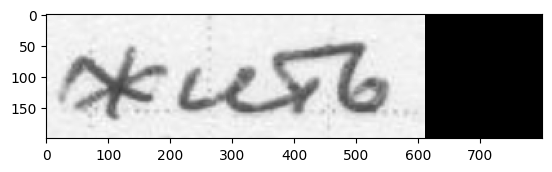

In [15]:
for input, _ in overfit_ds.take(1):
    plt.imshow(input['img_input'][0, :, :, 0], cmap="gray", interpolation="nearest")
    print(f"Real label: {train_labels[0]}")

# Actual training

In [19]:
# important: monitoring val_loss instead of val_cer because sometimes char predictions take a bit to kick in
early = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
reduce = ReduceLROnPlateau(monitor="val_loss", mode='min', factor=0.2, patience=5, min_lr=10e-6)
board = TensorBoard(log_dir=LOG_DIR)
callbacks = CustomCallbacks(val_ds) # learning rate logged by default with the reduce callback

model.fit(train_ds, validation_data=val_ds, epochs=1000, callbacks=[callbacks, reduce, early, board])

Epoch 1/1000
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - loss: 903.8912
['знать', 'несовершеннолетний', 'Бомбообразные', 'можно', 'Приказ']
['по', 'о', 'по', 'по', 'по']
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 411s 226ms/step - loss: 839.8381 - val_loss: 819.6335 - val_cer: 0.9105 - val_ewm: 0.0012 - val_blank_ratio: 0.9606 - val_len_ratio: 0.2649 - learning_rate: 0.0010
Epoch 2/1000
1807/1808 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 818.2165
['знать', 'несовершеннолетний', 'Бомбообразные', 'можно', 'Приказ']
['о', 'ои', 'о', 'о', 'о']
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 399s 220ms/step - loss: 816.6570 - val_loss: 817.3835 - val_cer: 0.9166 - val_ewm: 0.0000e+00 - val_blank_ratio: 0.9767 - val_len_ratio: 0.1564 - learning_rate: 0.0010
Epoch 3/1000
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step - loss: 795.6771
['знать', 'несовершеннолетний', 'Бомбообразные', 'можно', 'Приказ']
['но', 'н', 'ни', 'н', 'врр']
1808/1808 ━━━━━━━━━━━━━━━━━━━━ 398s 220ms/step - loss: 784.6279 - val_loss: 755.8782 - val

In [27]:
y_pred = model.predict(overfit_ds)

print(decode_output(y_pred))
truths = []
for imgs, labels in overfit_ds:
    for seq in labels.numpy():
        seq = seq[seq != 0]
        truths.append(b"".join(label_to_str(seq).numpy()).decode("utf-8"))
print(truths)
model.save("modelFULL.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
['жить', 'Азвсного', 'по прот', 'нем', 'двиланенного']
['жить', 'Азовского', 'по рот', 'нем', 'двигательного']
